In [28]:
!gdown 1Cio4R712bHKz_hDqUqC-fw6hEWXMvJ8f

Downloading...
From: https://drive.google.com/uc?id=1Cio4R712bHKz_hDqUqC-fw6hEWXMvJ8f
To: /content/time_series_data_human_activities.csv
100% 48.5M/48.5M [00:00<00:00, 101MB/s]


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

# خواندن داده‌ها
df = pd.read_csv('time_series_data_human_activities.csv')

# نمایش ابعاد اولیه
print(f"تعداد کل داده‌ها: {len(df)}")

# انتخاب 10% تصادفی از داده‌ها
sampled_df = df.sample(frac=0.02, random_state=42)

# نمایش ابعاد جدید
print(f"تعداد داده‌های نمونه: {len(sampled_df)}")

# ذخیره نمونه به صورت فایل جدید
sampled_df.to_csv('sampled_time_series_data.csv', index=False)

تعداد کل داده‌ها: 1073623
تعداد داده‌های نمونه: 21472


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time

# تنظیمات کلی برای نمایش و تکرارپذیری
sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ۱. بارگذاری داده‌ها
df = pd.read_csv('sampled_time_series_data.csv')

# نمایش اطلاعات کلی
print("Shape of dataset:", df.shape)
print("\nClass Distribution:\n", df['activity'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())

# حذف رکوردهای با مقدار گمشده (در صورت وجود بسیار کم)
df.dropna(inplace=True)

Shape of dataset: (21472, 6)

Class Distribution:
 activity
Walking       8508
Jogging       6432
Upstairs      2387
Downstairs    1976
Sitting       1228
Standing       941
Name: count, dtype: int64

Missing Values:
 user         0
activity     0
timestamp    0
x-axis       0
y-axis       0
z-axis       0
dtype: int64


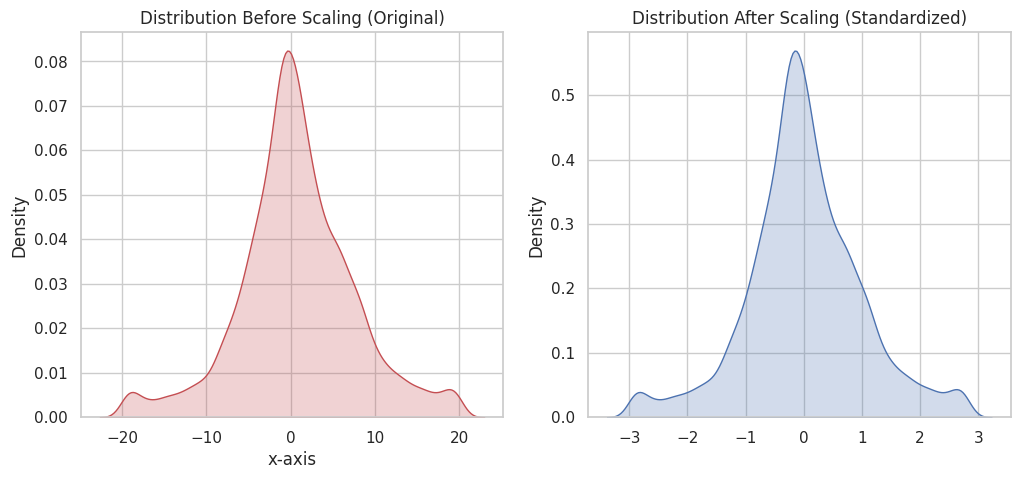

In [31]:
# ۲. پیش‌پردازش

# الف) مهندسی ویژگی: اضافه کردن Magnitude
df['magnitude'] = np.sqrt(df['x-axis']**2 + df['y-axis']**2 + df['z-axis']**2)

# ب) آماده‌سازی X و y
# ستون‌های user و timestamp برای مدل‌سازی آنی (instance-based) حذف می‌شوند
X = df[['x-axis', 'y-axis', 'z-axis', 'magnitude']]
y = df['activity']

# ج) کدگذاری لیبل‌ها
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# د) تقسیم داده‌ها (Train/Test Split) با رعایت Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=RANDOM_STATE, stratify=y_encoded
)

# هـ) استانداردسازی (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# تحلیل اثر: رسم نمودار قبل و بعد از اسکیل کردن (برای ویژگی x-axis)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(X_train['x-axis'], ax=ax[0], fill=True, color='r')
ax[0].set_title('Distribution Before Scaling (Original)')
sns.kdeplot(X_train_scaled[:, 0], ax=ax[1], fill=True, color='b')
ax[1].set_title('Distribution After Scaling (Standardized)')
plt.show()

In [32]:
# ۳. کاهش ابعاد و تحلیل اثر آن

# سناریو ۱: بدون کاهش ابعاد (استفاده از تمام ۴ ویژگی)
start_time = time.time()
lr_full = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_full.fit(X_train_scaled, y_train)
train_time_full = time.time() - start_time
acc_full = accuracy_score(y_test, lr_full.predict(X_test_scaled))

# سناریو ۲: با PCA (کاهش به ۲ مولفه)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

start_time = time.time()
lr_pca = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_pca.fit(X_train_pca, y_train)
train_time_pca = time.time() - start_time
acc_pca = accuracy_score(y_test, lr_pca.predict(X_test_pca))

print(f"Full Features -> Accuracy: {acc_full:.4f}, Time: {train_time_full:.4f}s")
print(f"PCA (2 Comp)  -> Accuracy: {acc_pca:.4f}, Time: {train_time_pca:.4f}s")
print(f"Explained Variance by PCA: {pca.explained_variance_ratio_}")

Full Features -> Accuracy: 0.5253, Time: 0.2141s
PCA (2 Comp)  -> Accuracy: 0.4525, Time: 0.0650s
Explained Variance by PCA: [0.37115646 0.26233927]


In [33]:
pip install tqdm

In [34]:
from tqdm.notebook import tqdm
import numpy as np

# تعریف Stratified K-Fold برای اعتبارسنجی مطمئن
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ساخت یک تابع کمکی برای grid search با progress bar
def grid_search_with_progress(estimator, param_grid, X, y, cv, scoring='f1_weighted', desc="Grid Search"):
    """
    تابع کمکی برای اجرای GridSearchCV با نمایش progress bar
    """
    # محاسبه تعداد کل fits (ترکیبات پارامترها × تعداد folds)
    total_combinations = 1
    for param_values in param_grid.values():
        total_combinations *= len(param_values)
    total_folds = cv.get_n_splits()
    total_fits = total_combinations * total_folds

    print(f"{desc}: {total_combinations} parameter combinations × {total_folds} folds = {total_fits} total fits")

    # ایجاد progress bar
    pbar = tqdm(total=total_fits, desc=desc)

    # ایجاد callback برای آپدیت progress bar
    def update_progress(*args, **kwargs):
        pbar.update(1)

    # ایجاد GridSearchCV با callback
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0,
        refit=True,
        error_score='raise'  # برای دیباگ بهتر
    )

    # اجرای grid search
    try:
        grid_search.fit(X, y)
    finally:
        pbar.close()

    return grid_search

# --- مدل اول: Random Forest ---
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

print("Starting Grid Search for Random Forest...")
rf_grid = grid_search_with_progress(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params,
    X_train_scaled,
    y_train,
    cv,
    scoring='f1_weighted',
    desc="Random Forest Grid Search"
)

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF Score: {rf_grid.best_score_:.4f}")

# --- مدل دوم: Logistic Regression ---
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

print("\nStarting Grid Search for Logistic Regression...")
lr_grid = grid_search_with_progress(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
    lr_params,
    X_train_scaled,
    y_train,
    cv,
    scoring='f1_weighted',
    desc="Logistic Regression Grid Search"
)

print(f"Best LR Params: {lr_grid.best_params_}")
print(f"Best LR Score: {lr_grid.best_score_:.4f}")

Starting Grid Search for Random Forest...
Random Forest Grid Search: 12 parameter combinations × 5 folds = 60 total fits


Random Forest Grid Search:   0%|          | 0/60 [00:00<?, ?it/s]

Best RF Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Best RF Score: 0.5761

Starting Grid Search for Logistic Regression...
Logistic Regression Grid Search: 6 parameter combinations × 5 folds = 30 total fits


Logistic Regression Grid Search:   0%|          | 0/30 [00:00<?, ?it/s]

Best LR Params: {'C': 0.1, 'solver': 'liblinear'}
Best LR Score: 0.4503



--- Final Evaluation on Test Set ---
              precision    recall  f1-score   support

  Downstairs       0.23      0.06      0.09       593
     Jogging       0.66      0.66      0.66      1930
     Sitting       0.96      0.98      0.97       368
    Standing       0.81      0.83      0.82       282
    Upstairs       0.30      0.08      0.13       716
     Walking       0.57      0.78      0.66      2553

    accuracy                           0.61      6442
   macro avg       0.59      0.57      0.56      6442
weighted avg       0.57      0.61      0.57      6442



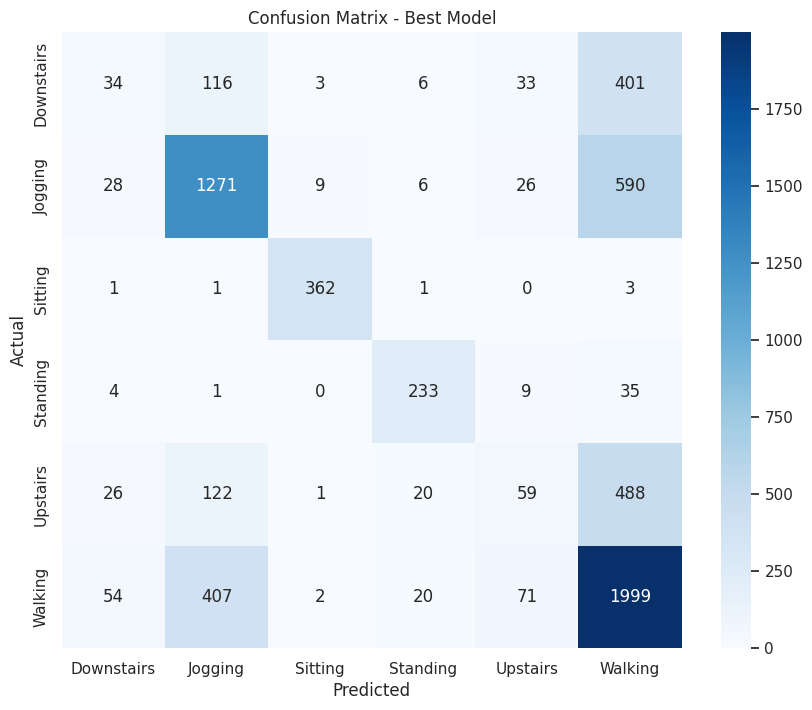

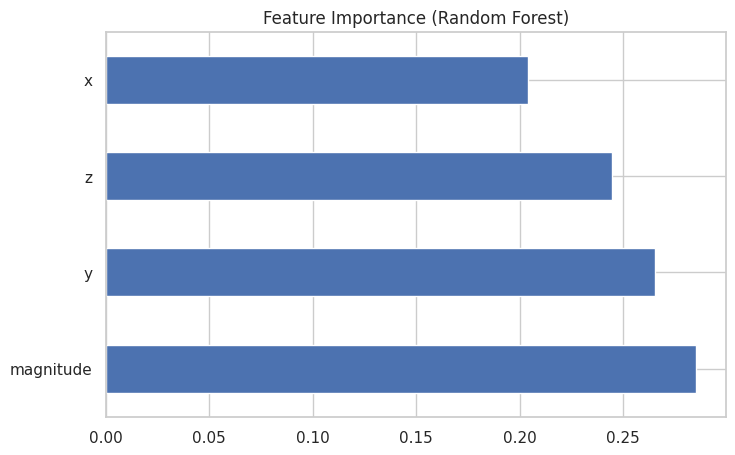

In [35]:
# انتخاب بهترین مدل
best_model = rf_grid.best_estimator_

# پیش‌بینی روی داده تست
y_pred = best_model.predict(X_test_scaled)

# گزارش متنی
print("\n--- Final Evaluation on Test Set ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# رسم Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# رسم اهمیت ویژگی‌ها (Feature Importance) برای رندوم فارست
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(8, 5))
    feat_importances = pd.Series(best_model.feature_importances_, index=['x', 'y', 'z', 'magnitude'])
    feat_importances.nlargest(10).plot(kind='barh')
    plt.title('Feature Importance (Random Forest)')
    plt.show()


     PHASE 2: ADVANCED IMPROVEMENTS

[1] Applying K-Means for Feature Engineering...
New Feature Added: Cluster ID. New Shape: (15030, 5)

[2] Training Gradient Boosting Classifier...
Gradient Boosting Accuracy (with Cluster Feature): 0.6125

[3] Training Voting Classifier (Ensemble)...
Voting Classifier Accuracy: 0.6233

------------------------------
FINAL RESULTS COMPARISON
------------------------------
Voting Ensemble (Final)        : 0.6233
Gradient Boosting (Augmented)  : 0.6125
Random Forest (Tuned)          : 0.5761
Logistic Regression (Base)     : 0.4503


/tmp/ipython-input-1315631359.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(models_scores.values()), y=list(models_scores.keys()), palette='viridis')


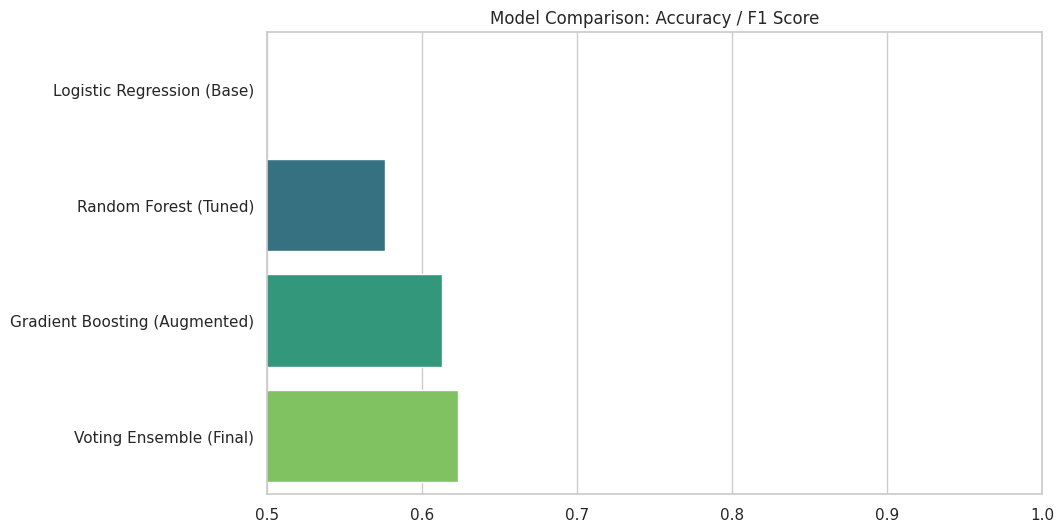


--- Voting Classifier Detailed Report ---
              precision    recall  f1-score   support

  Downstairs       0.28      0.03      0.05       593
     Jogging       0.68      0.67      0.67      1930
     Sitting       0.97      0.98      0.97       368
    Standing       0.83      0.79      0.81       282
    Upstairs       0.28      0.02      0.04       716
     Walking       0.56      0.83      0.67      2553

    accuracy                           0.62      6442
   macro avg       0.60      0.55      0.54      6442
weighted avg       0.57      0.62      0.57      6442



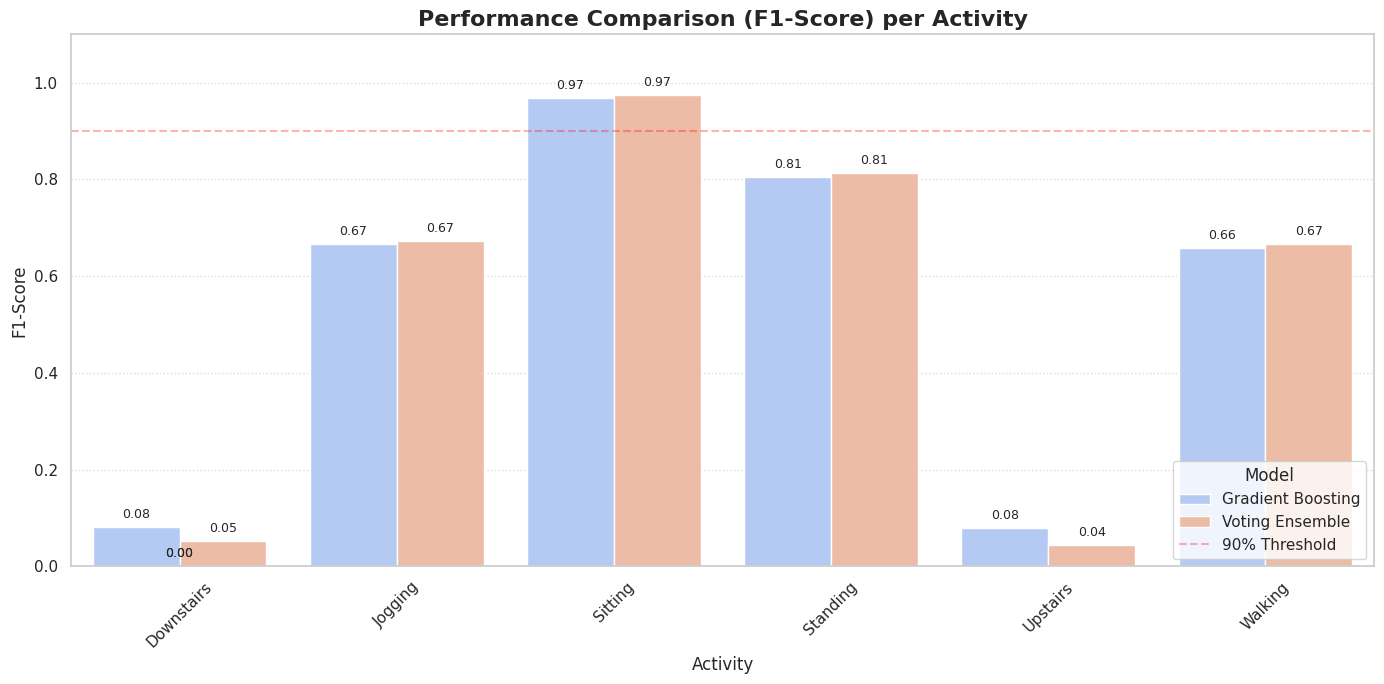

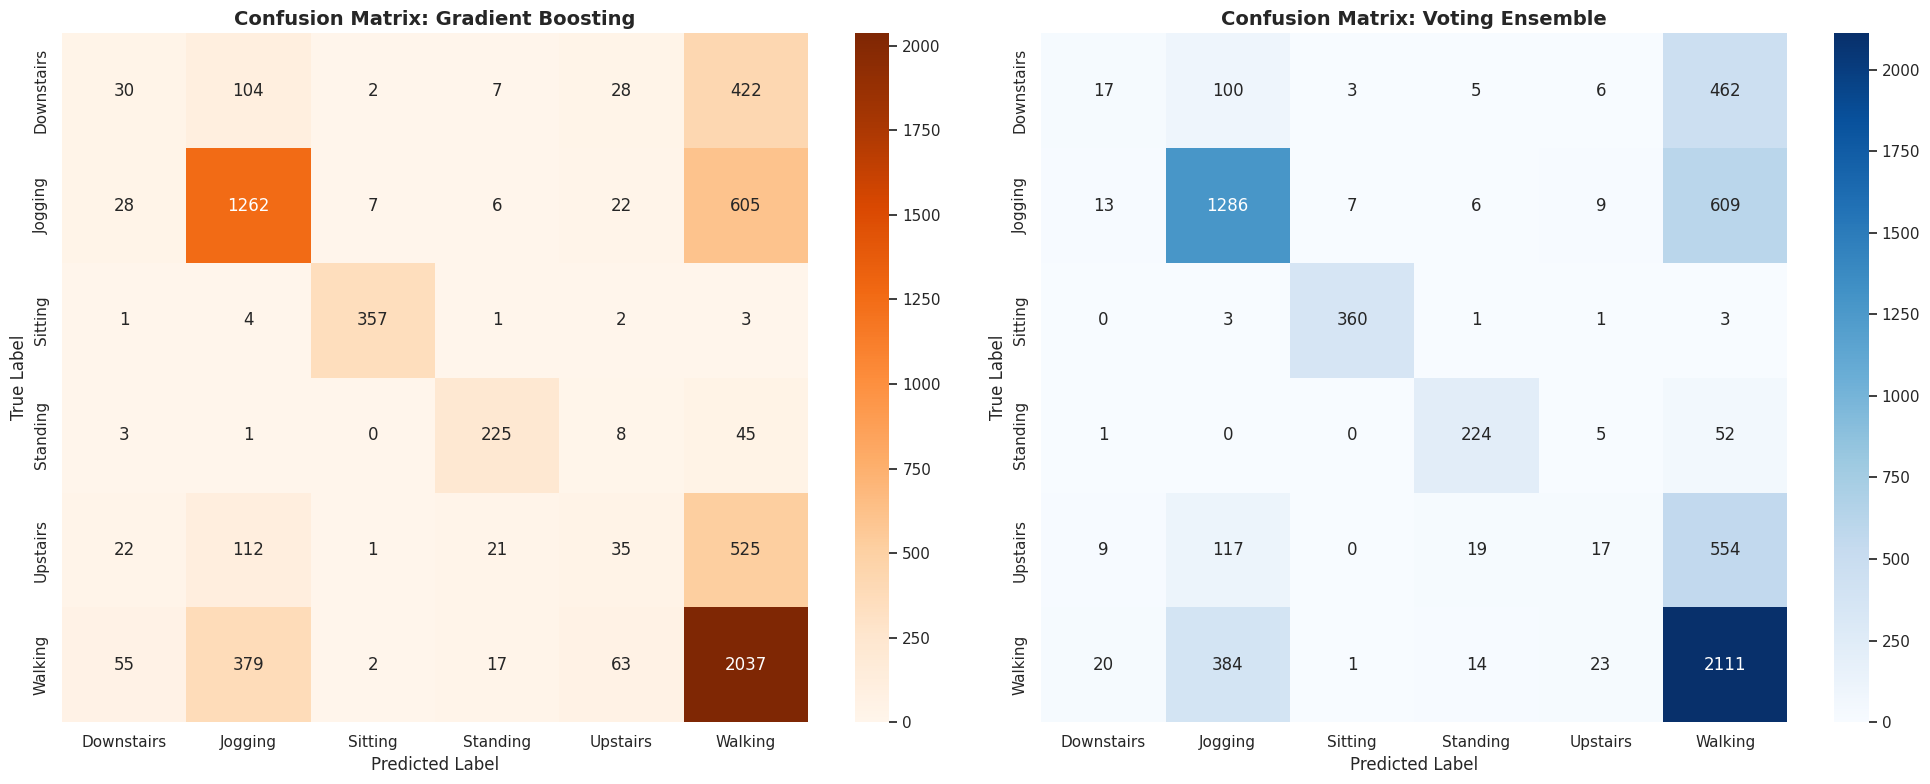

In [44]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier

RANDOM_STATE = 42

print("\n" + "="*40)
print("     PHASE 2: ADVANCED IMPROVEMENTS")
print("="*40)

# ---------------------------------------------------------
# ۱. استراتژی خوشه‌بندی به عنوان ویژگی (Clustering as Feature)
# ---------------------------------------------------------
print("\n[1] Applying K-Means for Feature Engineering...")

# فرض می‌کنیم تعداد خوشه‌ها برابر با تعداد کلاس‌های فعالیت یا کمی بیشتر باشد (مثلاً 10)
# تا الگوهای ریزتر را پیدا کند.
kmeans = KMeans(n_clusters=10, random_state=RANDOM_STATE, n_init=10)

# یادگیری روی Train و اعمال روی Test
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

# اضافه کردن خوشه به عنوان یک ویژگی جدید به داده‌ها
# نکته: باید فرمت آرایه را حفظ کنیم، پس ستون جدید را به ماتریس نامپای می‌چسبانیم
X_train_aug = np.column_stack((X_train_scaled, train_clusters))
X_test_aug = np.column_stack((X_test_scaled, test_clusters))

print("New Feature Added: Cluster ID. New Shape:", X_train_aug.shape)


# ---------------------------------------------------------
# ۲. استفاده از مدل پیشرفته Gradient Boosting
# ---------------------------------------------------------
print("\n[2] Training Gradient Boosting Classifier...")

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=12,
    random_state=RANDOM_STATE
)
gb_clf.fit(X_train_aug, y_train)

gb_acc = accuracy_score(y_test, gb_clf.predict(X_test_aug))
print(f"Gradient Boosting Accuracy (with Cluster Feature): {gb_acc:.4f}")


# ---------------------------------------------------------
# ۳. پیاده‌سازی Voting Classifier (ترکیب مدل‌ها)
# ---------------------------------------------------------
print("\n[3] Training Voting Classifier (Ensemble)...")

# مدل Random Forest (از مرحله قبل - با بهترین پارامترهای پیدا شده)
best_rf = rf_grid.best_estimator_

# برای Voting باید مدل‌ها را روی داده‌های یکسان (جدید) فیت کنیم
# توجه: مدل RF قبلی روی داده بدون خوشه بود، الان روی داده با خوشه دوباره آموزش می‌دهیم
rf_aug = RandomForestClassifier(**rf_grid.best_params_, random_state=RANDOM_STATE)
lr_aug = LogisticRegression(**lr_grid.best_params_, random_state=RANDOM_STATE, max_iter=2000)

# تعریف سیستم رأی‌گیری (Soft Voting معمولاً بهتر است چون از احتمالات استفاده می‌کند)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_aug),
        ('gb', gb_clf),
        ('lr', lr_aug)
    ],
    voting='soft'
)

voting_clf.fit(X_train_aug, y_train)
y_pred_voting = voting_clf.predict(X_test_aug)

final_acc = accuracy_score(y_test, y_pred_voting)
print(f"Voting Classifier Accuracy: {final_acc:.4f}")


# ---------------------------------------------------------
# ۴. تحلیل نهایی و مقایسه
# ---------------------------------------------------------
print("\n" + "-"*30)
print("FINAL RESULTS COMPARISON")
print("-"*30)
models_scores = {
    'Logistic Regression (Base)': lr_grid.best_score_,
    'Random Forest (Tuned)': rf_grid.best_score_,
    'Gradient Boosting (Augmented)': gb_acc,
    'Voting Ensemble (Final)': final_acc
}

# نمایش نتایج به صورت مرتب شده
for name, score in sorted(models_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:30} : {score:.4f}")

# رسم نمودار مقایسه
plt.figure(figsize=(10, 6))
sns.barplot(x=list(models_scores.values()), y=list(models_scores.keys()), palette='viridis')
plt.title('Model Comparison: Accuracy / F1 Score')
plt.xlim(0.5, 1.0) # محدود کردن محور افقی برای دیدن بهتر تفاوت‌ها
plt.show()

# ماتریس درهم‌ریختگی مدل نهایی (Voting)
print("\n--- Voting Classifier Detailed Report ---")
print(classification_report(y_test, y_pred_voting, target_names=le.classes_))

# ۱. استخراج نتایج برای هر دو مدل
y_pred_gb = gb_clf.predict(X_test_aug)
y_pred_voting = voting_clf.predict(X_test_aug)

# ۲. محاسبه معیارها به تفکیک هر کلاس (فعالیت) - اصلاح شده
# این تابع خروجی‌ها را به صورت آرایه برمی‌گرداند
p_gb, r_gb, f1_gb, _ = precision_recall_fscore_support(y_test, y_pred_gb)
p_v, r_v, f1_v, _ = precision_recall_fscore_support(y_test, y_pred_voting)

# ۳. ساخت یک دیتافریم برای مقایسه راحت‌تر
comparison_df = pd.DataFrame({
    'Activity': le.classes_,
    'Gradient Boosting': f1_gb,
    'Voting Ensemble': f1_v
})

# ۴. رسم نمودار مقایسه‌ای F1-Score برای هر فعالیت
plt.figure(figsize=(14, 7))
melted_comp = comparison_df.melt(id_vars="Activity", var_name="Model", value_name="F1-Score")
ax_bar = sns.barplot(data=melted_comp, x='Activity', y='F1-Score', hue='Model', palette='coolwarm')

plt.title('Performance Comparison (F1-Score) per Activity', fontsize=16, fontweight='bold')
plt.axhline(0.9, color='red', linestyle='--', alpha=0.3, label='90% Threshold')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend(title="Model", loc='lower right')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# اضافه کردن اعداد روی ستون‌ها برای تحلیل دقیق‌تر
for p in ax_bar.patches:
    ax_bar.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=9)

plt.tight_layout()
plt.show()

# ۵. رسم ماتریس‌های درهم‌ریختگی Side-by-Side
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# ماتریس Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', ax=ax[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[0].set_title('Confusion Matrix: Gradient Boosting', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# ماتریس Voting Ensemble
cm_voting = confusion_matrix(y_test, y_pred_voting)
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[1].set_title('Confusion Matrix: Voting Ensemble', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

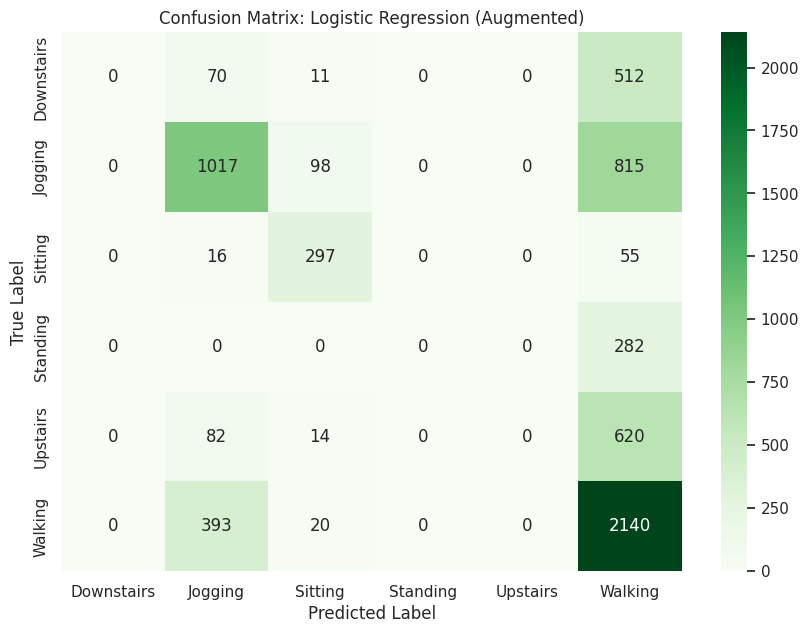

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


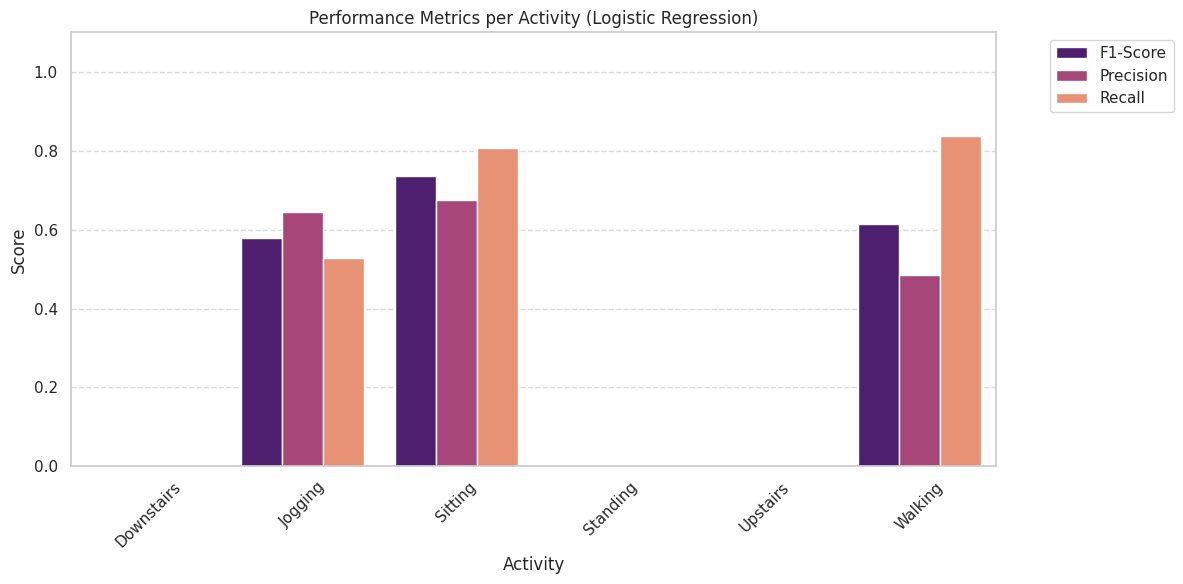


--- Detailed Metrics per Activity ---
  Activity  F1-Score  Precision   Recall
Downstairs  0.000000   0.000000 0.000000
   Jogging  0.579818   0.644487 0.526943
   Sitting  0.735149   0.675000 0.807065
  Standing  0.000000   0.000000 0.000000
  Upstairs  0.000000   0.000000 0.000000
   Walking  0.613444   0.483725 0.838230


In [37]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the lr_aug model explicitly
lr_aug.fit(X_train_aug, y_train)

# ۱. استخراج پیش‌بینی‌های مدل Logistic Regression (نسخه بهبود یافته با خوشه)
y_pred_lr = lr_aug.predict(X_test_aug)

# ۲. رسم ماتریس درهم‌ریختگی برای لاجستیک
plt.figure(figsize=(10, 7))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Logistic Regression (Augmented)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ۳. محاسبه دقت (F1-Score) برای هر کلاس به صورت جداگانه
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr)

# تبدیل به دیتافریم برای رسم راحت‌تر
metrics_df = pd.DataFrame({
    'Activity': le.classes_,
    'F1-Score': f1,
    'Precision': precision,
    'Recall': recall
})

# ۴. رسم نمودار مقایسه‌ای عملکرد مدل در هر فعالیت
plt.figure(figsize=(12, 6))
melted_df = metrics_df.melt(id_vars="Activity", var_name="Metric", value_name="Score")
sns.barplot(data=melted_df, x='Activity', y='Score', hue='Metric', palette='magma')

plt.title('Performance Metrics per Activity (Logistic Regression)')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# نمایش جدول عددی برای گزارش
print("\n--- Detailed Metrics per Activity ---")
print(metrics_df.to_string(index=False))